In [1]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import cv2

#import data

In [ ]:
!git clone https://github.com/alitourani/Iranis-dataset.git

In [ ]:
!unzip '/content/Iranis-dataset/Iranis Dataset Files.zip' -d '/content/dataset'

In [4]:
base_dir = r"/content/dataset"
data = []

if not os.path.exists(base_dir):
    print(f"Error: The directory '{base_dir}' does not exist.")
else:
    for class_name in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_name)

        if os.path.isdir(class_path):

            for image_name in os.listdir(class_path):
                image_path = os.path.join(class_path, image_name)

                data.append({
                    'address': image_path,  # مسیر کامل ذخیره می‌شود
                    'labels': class_name
                })

df = pd.DataFrame(data)
print(df.head())

                           address labels
0  /content/dataset/0/0 (2423).jpg      0
1  /content/dataset/0/0 (2227).jpg      0
2   /content/dataset/0/0 (453).jpg      0
3  /content/dataset/0/0 (2343).jpg      0
4  /content/dataset/0/0 (2121).jpg      0


In [5]:
# حذف random_state برای داشتن یک Shuffle کاملاً تصادفی و متفاوت در هر بار اجرا
df_shuffled = df.sample(frac=1).reset_index(drop=True)

# چاپ ۵ ردیف اول برای مشاهده نتیجه بُر خورده
print("Shuffled DataFrame:")
print("-" * 40)
print(df_shuffled.head(10))

Shuffled DataFrame:
----------------------------------------
                               address labels
0      /content/dataset/B/B (1146).jpg      B
1      /content/dataset/T/Ta (503).jpg      T
2      /content/dataset/Y/Y (1429).jpg      Y
3  /content/dataset/PuV/PuV (2185).jpg    PuV
4  /content/dataset/Sad/Sad (2167).jpg    Sad
5      /content/dataset/5/5 (1784).jpg      5
6      /content/dataset/2/2 (1341).jpg      2
7       /content/dataset/6/6 (987).jpg      6
8      /content/dataset/Y/Y (1972).jpg      Y
9   /content/dataset/PuV/PuV (291).jpg    PuV


# transform

In [6]:
def create_color_tensors_string_labels(dataframe):
    features = []
    labels = []

    for index, row in dataframe.iterrows():
        img_path = row['address']
        label_name = row['labels']

        # ۱. خواندن عکس به صورت رنگی
        img_matrix = cv2.imread(img_path)

        if img_matrix is not None:
            # ۲. تبدیل فرمت رنگ از BGR به RGB
            img_matrix = cv2.cvtColor(img_matrix, cv2.COLOR_BGR2RGB)

            # ۳. تغییر سایز به ۲۸ در ۲۸
            img_matrix = cv2.resize(img_matrix, (28, 28))

            features.append(img_matrix)

            # مستقیماً خود اسم متنی کلاس را ذخیره می‌کنیم
            labels.append(label_name)
        else:
            print(f"Warning: Could not read {img_path}")

    # ۴. تبدیل نهایی به آرایه‌های نامپای
    train_features = np.array(features)
    train_labels = np.array(labels) # این آرایه حالا شامل رشته‌های متنی است

    return train_features, train_labels

# --- اجرای کد ---
train_features, train_labels = create_color_tensors_string_labels(df_shuffled)

print("-" * 30)
print(f"train-features : {train_features.shape}")
print(f"train-labels   : {train_labels.shape}")
print("-" * 30)
# چاپ ۵ لیبل اول برای اطمینان از اینکه متن هستند
print(f"Sample labels  : {train_labels[:5]}")

------------------------------
train-features : (83844, 28, 28, 3)
train-labels   : (83844,)
------------------------------
Sample labels  : ['B' 'T' 'Y' 'PuV' 'Sad']


In [7]:
train_features, test_features, train_labels, test_labels = train_test_split(
    train_features,
    train_labels,
    test_size=0.1,
    random_state=42
)

# بررسی ابعاد داده‌های تقسیم شده
print("-" * 30)
print(f"Train features shape : {train_features.shape}")
print(f"Train labels shape   : {train_labels.shape}")
print(f"Test features shape  : {test_features.shape}")
print(f"Test labels shape    : {test_labels.shape}")
print("-" * 30)

------------------------------
Train features shape : (75459, 28, 28, 3)
Train labels shape   : (75459,)
Test features shape  : (8385, 28, 28, 3)
Test labels shape    : (8385,)
------------------------------


label img: Sad
img shape: (28, 28, 3)


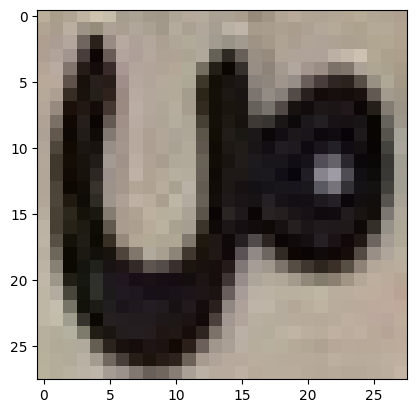

In [8]:
idx = 10
print(f'label img: {train_labels[idx]}')
print(f'img shape: {train_features[idx].shape}')
# plt.gray()
plt.imshow(train_features[idx])

# preprocessing image

In [9]:
print(f'(number of pixel)\nminimum : {np.min(train_features[0])}\nmaxmum : {np.max(train_features[0])}')

(number of pixel)
minimum : 48
maxmum : 214


In [10]:
# @title normalaze image between 0,1
train_features = train_features/255.0
test_features = test_features/255.0

In [11]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
le.fit(train_labels)

train_labels_int = le.transform(train_labels)
test_labels_int = le.transform(test_labels)

train_labels_final = to_categorical(train_labels_int)
test_labels_final = to_categorical(test_labels_int)

print("تبدیل با موفقیت انجام شد!")
print(f"شکل نهایی لیبل‌های آموزش: {train_labels_final.shape}")

تبدیل با موفقیت انجام شد!
شکل نهایی لیبل‌های آموزش: (75459, 28)


In [32]:
for index, class_name in enumerate(le.classes_):
    print(f"Index {index} is class: {class_name}")

Index 0 is class: 0
Index 1 is class: 1
Index 2 is class: 2
Index 3 is class: 3
Index 4 is class: 4
Index 5 is class: 5
Index 6 is class: 6
Index 7 is class: 7
Index 8 is class: 8
Index 9 is class: 9
Index 10 is class: A
Index 11 is class: B
Index 12 is class: D
Index 13 is class: Gh
Index 14 is class: H
Index 15 is class: J
Index 16 is class: L
Index 17 is class: M
Index 18 is class: N
Index 19 is class: P
Index 20 is class: PuV
Index 21 is class: PwD
Index 22 is class: Sad
Index 23 is class: Sin
Index 24 is class: T
Index 25 is class: Taxi
Index 26 is class: V
Index 27 is class: Y


# model settings

In [12]:
model = keras.Sequential()
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(units=128, activation='relu'))
model.add(keras.layers.Dense(units=128, activation='relu'))
model.add(keras.layers.Dense(units=28 , activation='softmax'))

In [13]:
model.compile(optimizer=tf.optimizers.Adam(), loss=tf.losses.categorical_crossentropy , metrics=['accuracy'])
earle_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)
model.build(input_shape=(None, 28, 28, 3))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       301,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,308 (1.23 MB)

 Trainable params: 321,308 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

# train

In [14]:
hist = model.fit(train_features, train_labels_final, batch_size=128, epochs=1000, validation_data=(test_features, test_labels_final), callbacks=[earle_stop])

590/590 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9978 - loss: 0.0083 - val_accuracy: 0.9932 - val_loss: 0.0539
Epoch 152/1000
590/590 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9976 - loss: 0.0111 - val_accuracy: 0.9922 - val_loss: 0.0789
Epoch 153/1000
590/590 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9976 - loss: 0.0103 - val_accuracy: 0.9919 - val_loss: 0.0770
Epoch 154/1000
590/590 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9974 - loss: 0.0113 - val_accuracy: 0.9930 - val_loss: 0.0652
Epoch 155/1000
590/590 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9983 - loss: 0.0075 - val_accuracy: 0.9921 - val_loss: 0.0681
Epoch 156/1000
590/590 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9970 - loss: 0.0140 - val_accuracy: 0.9946 - val_loss: 0.0611
Epoch 157/1000
590/590 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9979 - loss: 0.0077 - val_accuracy: 0.9952 - val_loss: 0.0619
Epoch 158/1000
590/590 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9982 - loss: 0.0069 -

# analysis

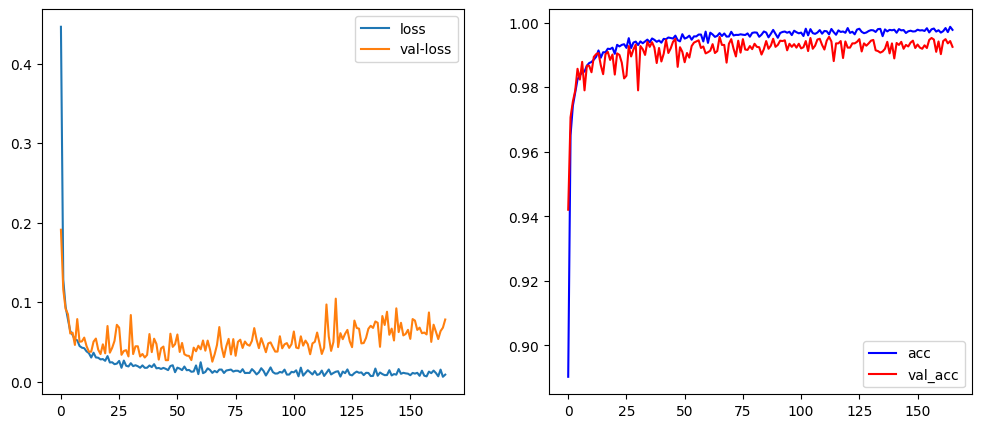

In [15]:
# @title Error rate
# loss
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.plot(hist.history['loss'],label='loss')
plt.plot(hist.history['val_loss'],label='val-loss')
plt.legend()
# accuracy
acc = hist.history['accuracy']
val_acc = hist.history['val_accuracy']
plt.subplot(1,2,2)
plt.plot(acc, color='blue', label='acc')
plt.plot(val_acc, color='red', label='val_acc')
plt.legend()
plt.show()

# output

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
feature : (28, 28, 3)
y_pred : 12
result : 1.0
['D']



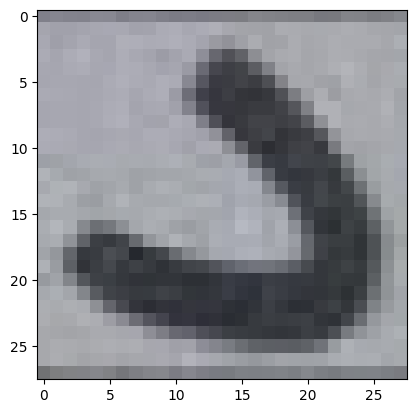

In [30]:
idx = 60
img = test_features[idx]
y_pred = model.predict(img.reshape(-1,28,28,3).astype('float32'))
print(f'feature : {img.shape}')
print(f'y_pred : {np.argmax(y_pred)}\nresult : {np.max(y_pred)}\n{le.inverse_transform([np.argmax(y_pred)])}\n')
plt.imshow(test_features[idx])

In [31]:
for index, class_name in enumerate(le.classes_):
    print(f"Index {index} is class: {class_name}")

Index 0 is class: 0
Index 1 is class: 1
Index 2 is class: 2
Index 3 is class: 3
Index 4 is class: 4
Index 5 is class: 5
Index 6 is class: 6
Index 7 is class: 7
Index 8 is class: 8
Index 9 is class: 9
Index 10 is class: A
Index 11 is class: B
Index 12 is class: D
Index 13 is class: Gh
Index 14 is class: H
Index 15 is class: J
Index 16 is class: L
Index 17 is class: M
Index 18 is class: N
Index 19 is class: P
Index 20 is class: PuV
Index 21 is class: PwD
Index 22 is class: Sad
Index 23 is class: Sin
Index 24 is class: T
Index 25 is class: Taxi
Index 26 is class: V
Index 27 is class: Y
